# Adjoint Optimization of Rectangular Patch Antennas

This notebook demonstrates the use of inverse design for the optimization of antennas. A simple rectangular patch antenna, as explored in our [Introduction to Antenna Simulation](https://www.flexcompute.com/tidy3d/examples/notebooks/AntennaCharacteristics/) notebook, is primarily defined by two parameters: its width and height. If you aren't familiar with it already, we strongly recommend going through [Introduction to Antenna Simulation](https://www.flexcompute.com/tidy3d/examples/notebooks/AntennaCharacteristics/) before this one as we will assume knowledge of the RF modeling workflow in tidy3d in this notebook. These are tuned to make the antenna resonate at a desired frequency and match the impedance of the feed line. Usually, these parameters can be found via intuitive design techniques and numerical formulas. However, in this example, we show a different strategy to tuning the antenna parameters. This notebook demonstrates gradient-based RF optimization in Tidy3D. This technique, enabled by the adjoint method and automatic differentiation (autograd), allows for the efficient and simultaneous optimization of all geometric parameters, also known as inverse design.

We illustrate this process through the straightforward optimization to find the ideal width and height of a rectangular patch antenna for a single target frequency. In future notebooks, we will build on this example and show more intricate patch antenna designs that take advantage of inverse design to simultaneously tune large numbers of geometric parameters to meet user-defined metrics with high performance. The optimization geometry is shown below. The antenna consists of a metallic patch on a substrate with a ground plane, is excited by an offset feed line, and radiates into free space. 

<div style="display: flex; gap: 10px; justify-content: center;">
    <img src="img/rf_autograd_1_patch_antenna_thumbnail.png" style="height:500px; object-fit: contain;"/>
</div>

In [1]:
import os
import pickle

import autograd.numpy as anp
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.plugins.smatrix as smatrix
from autograd import value_and_grad
from rich.console import Console
from rich.text import Text
from tidy3d.plugins.autograd import adam, apply_updates
from tidy3d.plugins.microwave import rf_material_library
from tidy3d.web import run

# Setup console and printing parameters for rich printing during optimization loops
console = Console()
print_decimal_places = 2  # how many decimal places to use in printing
print_iteration_frequency = 5  # how often to print optimization progress

## Configuration and Parameters

In this first section, we set up a variety of parameters for the optimization, including the frequency bands (specified in Hz) and resonance target as well as useful geometric parameters. Similar to other RF examples, we introduce a scaling factor to convert the default unit in Tidy3D of micrometers to millimeters (mm), which is more commonly used in antenna simulations. Thus, the default unit when looking at constants in this notebook is millimeters.

In [2]:
# length scales and geometric parameters for optimization
mm = 1e3  # mm scaling

# feedline parameters
feed_x = 2.46 * mm  # width of feed
feed_y = 20 * mm  # length of feed
feed_offset = 2.09 * mm  # feed offset from center of patch

# substrate geometric parameters
sub_width = 23.34 * mm
sub_height_extension = 25 * mm

sub_x = [-0.5 * sub_width, 0.5 * sub_width]
sub_y = [-feed_y, sub_height_extension]
sub_z = 0.68 * mm

# center and size for placing directivity and far field monitors to capture radiation from the
# antenna patch
directivity_center_x = np.mean(sub_x)
directivity_center_y = np.mean(sub_y)
directivity_size_x = 5 * mm + sub_x[1] - sub_x[0]
directivity_size_y = 5 * mm + sub_y[1] - sub_y[0]

# frequency range (Hz) for simulating
freq_start = 7e9
freq_stop = 11e9
# simulation frequencies to cover enough bandwidth for evaluating and optimizing antennas
opt_sim_freqs = [8e9, 10e9]

freq0 = 0.5 * (freq_start + freq_stop)  # central frequency
wavelength0 = td.C_0 / freq0  # wavelength of central frequency in vacuum

# frequencies for computing S-parameters of antennas
freqs_s_params = np.linspace(freq_start, freq_stop, 200)

# frequencies for optimizing different
opt_freqs = [8.25e9]  # single patch target frequency

# set ranges of theta and phi to record directivity for
theta_directivity = np.linspace(-np.pi, np.pi, 201)
phi_directivity = np.linspace(0, np.pi, 101)

# set the optimization theta, phi grid for enhancing directivity around theta=0
num_theta_opt_points = 12
theta_opt = theta_directivity[
    (len(theta_directivity) // 2) - (num_theta_opt_points // 2) : (len(theta_directivity) // 2)
    + (num_theta_opt_points // 2)
    + 1
]
phi_opt = phi_directivity  # use the full phi sweep, but limit the theta points to be centered around 0 degrees

# materials for optimization
air = td.Medium()  # set up the antennas so they radiate into air
# choose common PCB material, ArlonAD255C, from the RF material library to use as substrate
sub_medium = rf_material_library["AD255C"]["design"]
PEC = td.PEC2D  # thickness-free PEC medium for antenna patches, feed lines, and the ground plane

## Create Simulation Objects

To prepare for the optimization, we need to make a base simulation that we can add the antenna geometry and excitation source to. This base simulation includes the ground plane and substrate, the two structures below the patch antenna. In this simulation, we also set up `LayerRefinementSpec` objects around our ground, substrate, and patch antenna layers. The fine mesh improves accuracy of both the simulation and PEC gradients. As in other RF examples, the source will be added later via a `LumpedPort`.

In [3]:
def create_base_sim():
    """
    Creates the base simulation for evaluating and optimizing patch antennas. The base simulation includes the
    substrate geometry, and ground plane. It also overrides a vertical slice of the simulation where the feed and
    patch will be placed with a fine mesh override to ensure accurate simulation and gradients near the PEC boundaries.
    """
    substrate_box = td.Box.from_bounds(
        [sub_x[0], sub_y[0], -sub_z / 2.0],
        [sub_x[1], sub_y[1], sub_z / 2.0],
    )
    # Define substrate structure
    substrate = td.Structure(
        geometry=substrate_box,
        medium=sub_medium,
    )

    # Define ground plane structure and assign the material by PEC
    ground_plane = td.Structure(
        geometry=substrate_box.updated_copy(
            center=list(substrate_box.center[0:2]) + [-sub_z / 2.0],
            size=list(substrate_box.size[0:2]) + [0],
        ),
        medium=PEC,
    )

    # list of structures for the simulation arranged first by dielectric and then PEC to
    # ensure PEC takes precedence at interfaces.
    structures_list = [substrate, ground_plane]

    # PML wavelength at 10 GHz
    wl_pml = wavelength0

    # quarter wavelength (at 10 GHz) padding on each side
    sim_x_size = sub_x[1] - sub_x[0] + wl_pml / 2.0
    sim_y_size = sub_y[1] - sub_y[0] + wl_pml / 2.0
    sim_y_center = np.mean(sub_y)

    sim_z_max = sub_z + 1.5 * wavelength0
    sim_z_min = sub_z - 0.5 * wavelength0
    sim_z_center = 0.5 * (sim_z_max + sim_z_min)
    sim_z_size = sim_z_max - sim_z_min

    # set a fine mesh for the corner refinement based on the center wavelength
    dl = wavelength0 / 200.0
    mesh_override_vertical_padding = 1 * mm

    layer_refinement_ground = td.LayerRefinementSpec.from_structures(
        axis=2, min_steps_along_axis=3, structures=[ground_plane]
    )

    layer_refinement_patch = td.LayerRefinementSpec(
        center=(0, sim_y_center, sub_z / 2),
        size=(td.inf, td.inf, mesh_override_vertical_padding),
        axis=2,
        min_steps_along_axis=3,
        corner_refinement=td.GridRefinement(dl=dl, num_cells=3),
    )

    layer_refinement_substrate = td.LayerRefinementSpec.from_structures(
        axis=2, structures=[substrate], min_steps_along_axis=3
    )

    # Truncate the computational domain by PMLs
    boundary_spec = td.BoundarySpec(
        x=td.Boundary.pml(),
        y=td.Boundary.pml(),
        z=td.Boundary.pml(),
    )

    # Create the simulation object
    base_sim = td.Simulation(
        center=[0.0, sim_y_center, sim_z_center],
        size=[sim_x_size, sim_y_size, sim_z_size],
        grid_spec=td.GridSpec.auto(
            min_steps_per_wvl=20,  # largest cell size is set to 20 cells per smallest wavelength.
            wavelength=td.C_0 / freq_stop,  # smallest wavelength to resolve
            layer_refinement_specs=[
                layer_refinement_ground,
                layer_refinement_substrate,
                layer_refinement_patch,
            ],
        ),
        structures=structures_list,
        sources=[],  # sources will be added by TerminalComponentModeler
        monitors=[],
        run_time=70 * (substrate.geometry.size[1] / td.C_0),
        boundary_spec=boundary_spec,
        plot_length_units="mm",  # this option will make plots default to units of millimeters.
    )

    return base_sim

In addition to the base simulation creation, we set up a function to add a feed line and PEC patches to a simulation object. Later, this will allow us to create an antenna with an arbitrary list of patches and insert it into our base simulation.

In [4]:
def create_simulation_with_patches(base_sim, patch_boxes, monitors):
    """
    Creates a new simulation from the base simulation that includes PEC patches for all of the Box
    objects in patch_boxes as well as adds a feed line.
    """
    patches = []
    for patch_box in patch_boxes:
        patches.append(td.Structure(geometry=patch_box, medium=PEC))

    feed_geometry = td.Box.from_bounds(
        [feed_offset - 0.5 * feed_x, -feed_y, sub_z / 2], [feed_offset + 0.5 * feed_x, 0, sub_z / 2]
    )

    feed = td.Structure(geometry=feed_geometry, medium=PEC)

    return base_sim.updated_copy(
        structures=list(base_sim.structures) + [feed] + patches,
        monitors=list(base_sim.monitors) + monitors,
    )

Finally, we set up a function to create a `LumpedPort` and `TerminalComponentModeler` that will generate the input excitation to the antenna. We can specify an impedance for the port as well as the desired frequencies for the resulting simulation. The `TerminalComponentModeler` will set up the simulations we need to evaluate and optimize the antenna.

In [5]:
def create_modeler(simulation, frequencies, radiation_monitors=(), port_impedance=50):
    """
    Creates the LumpedPort and TerminalComponentModeler based on a `simulation`, the desired
    simulation `frequencies`, `radiation_monitors` for computing directivity, and a `port_impedance`.
    """
    # Setup a LumpedPort for the TerminalComponentModeler, which is needed
    # to end the port with a matched load as well as providing a source for the simulation.
    port = smatrix.LumpedPort(
        center=[feed_offset, -feed_y, 0],
        size=[feed_x, 0, sub_z],
        voltage_axis=2,
        name="lumped_port",
        impedance=port_impedance,
    )

    # We integrate the base simulation with the LumpedPort using the TerminalComponentModeler.
    # This allows us to compute scattering parameters and extract any additional data needed from the simulation.
    modeler = smatrix.TerminalComponentModeler(
        simulation=simulation,
        ports=[port],
        freqs=frequencies,
        remove_dc_component=False,  # include DC component for more accuracy at low frequencies
        radiation_monitors=radiation_monitors,
    )

    return modeler

## Setup Plotting and Evaluation Functions

Here, we set up some helper functions to aid in plotting antenna geometry and evaluating antenna characteristics before and after optimizations. First, we set up a function to plot the antenna structure and feed line along with the surrounding mesh. Near PEC edges, especially when computing gradients, we recommend using a fine mesh. In this function, we can also observe the location where the input source is fed into the antenna to confirm it is at the end of the feed line. **Note: the plotting functions below are useful for visualizations in this notebook, but their internals are not crucial to the understanding of how to set up and run gradient based RF optimizations in tidy3d. Feel free to skim this section and skip to the next section ("Demonstrating Gradient Based Optimization of a Patch Antenna") whenever you're ready.**

In [6]:
def plot_structures_and_mesh(patch_boxes):
    """Plots the antenna structure and surrounding mesh to ensure it looks as expected before running simulations."""
    base_sim = create_base_sim()

    no_additional_monitors = []
    sim_with_patches = create_simulation_with_patches(base_sim, patch_boxes, no_additional_monitors)

    fig, ax = plt.subplots()

    # examine the structure and mesh in the x-y plane
    sim_with_patches.plot(
        z=sub_z / 2,
        ax=ax,
        monitor_alpha=0.2,
    )
    sim_with_patches.plot_grid(z=sub_z / 2, ax=ax)

    plt.show()

Second, we set up a function that can calculate `S11` and realized antenna gain for each polarization. `S11` is the voltage reflection coefficient and $|S_{11}|^2$ is the power reflection coefficient or in other words, the reflected power divided by the input power. A good antenna will have a small `S11` at its operating frequencies. `S11` is plotted in dB and thus at resonance, we will see a large, negative value corresponding to low reflection. Before and after an optimization, this is one way to evaluate how well the optimization tuned the geometry for the correct frequencies. In the realized gain plot, we can see how efficiently energy is radiating from the antenna and in what direction when compared to an isotropic radiator. For simplicity and to keep plots less crowded, we collect the realized gain for the optimization frequencies while we compute `S11` value over a broad spectrum.

In [7]:
def evaluate_antenna(patch_params, eval_s_params_freqs):
    """
    Evaluate the S11 parameter and realized gain in both polarizations for the given antenna geometry.
    The S11 is calculated across a broad spectrum while the realized gain is only computed for the opt_freqs.
    """
    patch_boxes = params_to_boxes(patch_params)

    base_sim = create_base_sim()
    no_additional_monitors = []
    sim_with_patches = create_simulation_with_patches(base_sim, patch_boxes, no_additional_monitors)

    monitor_directivity = td.DirectivityMonitor(
        center=[directivity_center_x, directivity_center_y, 0],
        size=(
            directivity_size_x,
            directivity_size_y,
            4 * mm,
        ),
        freqs=opt_freqs,
        name="directivity",
        phi=list(phi_directivity),
        theta=list(theta_directivity),
        far_field_approx=True,
    )

    # we only need whatever frequencies are unique in these two lists to have all the data we need for computing
    # S11 and gain
    eval_freqs = np.unique(list(eval_s_params_freqs) + list(opt_freqs))

    modeler = create_modeler(sim_with_patches, eval_freqs, radiation_monitors=[monitor_directivity])
    smatrix_data = run(modeler, task_name="smatrix", verbose=False)

    antenna_parameters_freq = smatrix_data.get_antenna_metrics_data(monitor_name="directivity")
    partial_realized_gain = antenna_parameters_freq.partial_realized_gain(pol_basis="linear")

    return smatrix_data, partial_realized_gain

Given the optimization results, we can plot the comparison of two antenna simulations using the `plot_antenna_comparison` function below. We can easily compare the initial and final optimization states to see how well the resulting antenna is performing in our desired metrics. During the optimization, we will also periodically save the `S11` and gain of the antenna. The function `plot_antenna_evolution` allows us to plot these metrics out so we can see how performance evolved over the course of the optimization.

In [8]:
def plot_antenna_comparison(
    s_matrix_list,
    sim_data_list,
    partial_realized_gain_list,
    plot_phi,
    plot_title="Antenna Simulation Comparison",
    sim_names=None,
    single_color_gain_plots=False,
    savefig_fname=None,
):
    """
    Plots a comparison of two sets of simulation data.

    Args:
        s_matrix_list: List of S-matrix objects [s_matrix_sim1, s_matrix_sim2].
        sim_data_list: List of sim_data objects [sim_data_sim1, sim_data_sim2],
                       where each sim_data contains a "radiation" DirectivityMonitor output.
        partial_realized_gain_list: List of realized gain in linear polarization for each simulation.
        plot_phi: The phi value to select in the realized gain data for plotting.
        plot_title: Optional title to specify for plot (default is "Antenna Simulation Comparison").
        sim_names: Optional list of names for simulations for clearer legends.
        single_color_gain_plots: Optional choice to use a single color for all the frequencies
                                 in the gain plot (True) or have each frequency a different
                                 color (False). Default is False.
        savefig_fname: An optional filename to save the resulting figure
    """

    num_simulations = len(s_matrix_list)
    if num_simulations != 2 or len(sim_data_list) != 2:
        print("Warning: This function is designed to compare exactly two simulations.")

    alphas = [0.5, 1.0]  # Alpha for sim1, sim2
    if sim_names is None or len(sim_names) != num_simulations:
        sim_names = [f"Sim {i + 1}" for i in range(num_simulations)]

    grid_spec_cols = 3  # S11 and realized gain for each polarization side-by-side
    fig_width = grid_spec_cols * 4.5
    fig_height = 6.5

    num_rows = 1

    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
    gs = fig.add_gridspec(num_rows, grid_spec_cols)
    axs_list = []

    # plot the S11 parameter comparison for each simulation
    ax_s11 = fig.add_subplot(gs[0, 0])
    axs_list.append(ax_s11)
    ax_s11.set_title("$S_{11}$ Coefficient")
    ax_s11.set_xlabel("Frequency (GHz)")
    ax_s11.set_ylabel("$|S_{11}|^2$ (dB)")

    for sim_idx in range(num_simulations):
        s_matrix = s_matrix_list[sim_idx]
        current_alpha = alphas[sim_idx]
        sim_label_name = sim_names[sim_idx]

        s11_freqs_ghz = s_matrix.data.coords["f"] / 1e9
        s11_data_selection = s_matrix.data.isel(port_out=0, port_in=0)

        s11_values_flat = s11_data_selection.values.flatten()
        s11_values_db = 20 * np.log10(np.abs(s11_values_flat))
        ax_s11.plot(
            s11_freqs_ghz,
            s11_values_db,
            alpha=current_alpha,
            label=f"{sim_label_name})",
        )

    for opt_freq in opt_freqs:
        ax_s11.axvline(x=opt_freq / 1e9, color="k", linestyle="--")

    ax_s11.set_ylim(-25, 2)
    ax_s11.grid(True)
    ax_s11.legend()

    # for each linear polarization component, plot the realized gain for each linear polarization
    polarization_components = ["Gtheta", "Gphi"]

    for pol_idx, pol_component in enumerate(polarization_components):
        ax_polar = fig.add_subplot(gs[0, 1 + pol_idx], projection="polar")
        axs_list.append(ax_polar)
        ax_polar.set_title(f"Realized Gain for {pol_component}")

        ax_polar.set_theta_direction(-1)
        ax_polar.set_theta_offset(np.pi / 2.0)
        ax_polar.grid(True)
        ax_polar.set_rlabel_position(22.5)

        overall_max_gain = -np.inf
        color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        for freq_idx, eval_freq in enumerate(opt_freqs):
            base_color = color_cycle[freq_idx % len(color_cycle)]
            if single_color_gain_plots:
                base_color = color_cycle[0]
            freq_label_for_legend = f"{eval_freq / 1e9:.2f} GHz"

            # Plot data for each simulation for the current frequency
            for sim_idx in range(num_simulations):
                current_alpha = alphas[sim_idx]

                if single_color_gain_plots:
                    base_color = color_cycle[sim_idx]

                realized_gain_data = partial_realized_gain_list[sim_idx][pol_component].sel(
                    f=eval_freq, phi=plot_phi, method="nearest"
                )

                gain_values_for_plot = realized_gain_data.squeeze().values

                current_max_val = np.max(gain_values_for_plot)
                if current_max_val > overall_max_gain:
                    overall_max_gain = current_max_val

                # Label only the second simulation's line (alpha=1.0) for the legend entry of this frequency
                label_to_use = f"{freq_label_for_legend} ({sim_names[sim_idx]})"
                ax_polar.plot(
                    theta_directivity,
                    gain_values_for_plot,
                    color=base_color,
                    alpha=current_alpha,
                    label=label_to_use,
                )

        ax_polar.set_rlim(0, overall_max_gain * 1.1 if overall_max_gain > 0 else 1.0)
        ax_polar.legend(title="Frequency (GHz)", loc="best", fontsize="small")

    fig.suptitle(plot_title, fontsize=16)

    if savefig_fname:
        plt.savefig(savefig_fname)

    plt.show()


def plot_antenna_evolution(s11_sq_dB, s11_f, partial_realized_gain, gain_freqs):
    """Plots the evolution of the antenna S11 and and realized gain throughout an optimization.
    Args:
        s11_sq_dB: List of |S11|^2 (in dB) at each point in optimization. The length should match the
                   length of `partial_realized_gain`
        s11_f: Frequencies for each S11 array
        partial_realized_gain: List of realized gain objects broken into linear polarization. The length
                               of this list should match the length of `s11_sq_dB`
        gain_freqs: List of frequencies for each realized gain object.
    """
    num_lines = len(s11_sq_dB)

    alphas = np.linspace(0.25, 1.0, num_lines)

    fig_width = 13.5
    fig_height = 6.5

    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=True)
    num_rows = 1
    grid_spec_cols = 3
    gs = fig.add_gridspec(num_rows, grid_spec_cols)
    axs_list = []

    ax_s11 = fig.add_subplot(gs[0, 0])
    axs_list.append(ax_s11)
    ax_s11.set_title("$S_{11}$ Coefficient")
    ax_s11.set_xlabel("Frequency (GHz)")
    ax_s11.set_ylabel("$|S_{11}|^2$ (dB)")

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx in range(0, num_lines):
        ax_s11.plot(s11_f, s11_sq_dB[idx], color=color_cycle[0], linewidth=1.5, alpha=alphas[idx])

    ax_s11.set_ylim(-25, 2)
    ax_s11.grid(True)

    def add_polar_sequence(grid_col, pol_component, title):
        ax_polar = fig.add_subplot(gs[0, grid_col], projection="polar")
        axs_list.append(ax_polar)
        ax_polar.set_title(f"Realized Gain for {pol_component}")

        ax_polar.set_theta_direction(-1)
        ax_polar.set_theta_offset(np.pi / 2.0)
        ax_polar.grid(True)
        ax_polar.set_rlabel_position(22.5)

        for idx in range(0, num_lines):
            partial_realized_gain_batch = partial_realized_gain[idx][pol_component]
            partial_realized_gain_batch = np.reshape(
                partial_realized_gain_batch, (len(gain_freqs), len(theta_directivity))
            )

            for freq_idx in range(0, len(gain_freqs)):
                gain_values_for_plot = partial_realized_gain_batch[freq_idx]

                ax_polar.plot(
                    theta_directivity,
                    gain_values_for_plot,
                    color=color_cycle[freq_idx],
                    alpha=alphas[idx],
                )

            ax_polar.set_title(title)

    add_polar_sequence(1, "Gtheta", "Realized Gain\n(Gtheta), phi=0")
    add_polar_sequence(2, "Gphi", "Realized Gain\n(Gphi), phi=0")

    plt.show()

We set up a function to plot the figure of merit trajectory of the optimization and compare the initial and final antenna geometries. This is an indication of how well the optimization worked as well as a demonstration of the overall change that occurred over the course of the optimization.

In [9]:
def plot_optimization_results(
    figure_of_merit, feed_rect, init_rectangles, final_rectangles, savefig_fname=None
):
    """
    Plots a main rectangle and two lists of other rectangles with specified styles.

    Args:
        figure_of_merit: Figure of merit for each iteration during the optimization.
        feed_rect: The rectangular corresponding to the feed line.
        init_rectangles: A list of rectangles corresponding to the initial state
                         of the optimization.
        final_rectangles: A list of rectangles corresponding to the final condition
                         of the optimization.
        savefig_fname: Optional filename to save the resulting figure.

    """
    fig, ax = plt.subplots(1, 2)
    ax[1].set_aspect("equal", adjustable="box")

    all_rects_params = []  # to store (x_bl, y_bl, width, height) for limit calculation

    # helper function to add a rectangle and collect its parameters
    def add_rectangle_to_plot(
        rect_obj, facecolor, alpha=1.0, edgecolor="black", linestyle="solid", legend=None
    ):
        """
        Adds a single rectangle to the plot and collects its parameters.

        Args:
            rect_obj: The rectangle object with 'center' and 'size'.
            facecolor: The face color of the rectangle.
            alpha: Optional transparency of the rectangle.
            edgecolor: Optional edge color of the rectangle.
            linestyle: Optional line style of the rectangle's border.
            legend: Optional legend entry to use for this rectangle.
        """
        center_x, center_y, _ = (coord / mm for coord in rect_obj.center)
        width, height, _ = (sz / mm for sz in rect_obj.size)

        # Calculate bottom-left corner coordinates
        bottom_left_x = center_x - width / 2
        bottom_left_y = center_y - height / 2

        all_rects_params.append((bottom_left_x, bottom_left_y, width, height))

        rect_patch = patches.Rectangle(
            (bottom_left_x, bottom_left_y),
            width,
            height,
            facecolor=facecolor,
            alpha=alpha,
            edgecolor=edgecolor,
            linestyle=linestyle,
            linewidth=1,  # Default linewidth for borders
            label=legend,
        )
        ax[1].add_patch(rect_patch)

    add_rectangle_to_plot(feed_rect, facecolor="gold", edgecolor="black")

    legends_init_rect = [
        "initial" if (idx == 0) else None for idx in range(0, len(init_rectangles))
    ]
    legends_final_rect = [
        "final" if (idx == 0) else None for idx in range(0, len(final_rectangles))
    ]

    # plot rectangles from the second list (gold)
    for idx, rect_obj in enumerate(final_rectangles):
        add_rectangle_to_plot(
            rect_obj, facecolor="gold", edgecolor="black", legend=legends_final_rect[idx]
        )  # Added black edge for consistency

    # plot rectangles from the first list (gray, 0.25 alpha, dotted black border)
    for idx, rect_obj in enumerate(init_rectangles):
        add_rectangle_to_plot(
            rect_obj,
            facecolor="gray",
            alpha=0.25,
            edgecolor="black",
            linestyle="dotted",
            legend=legends_init_rect[idx],
        )

    # calculate plot limits
    if all_rects_params:
        min_x = min(p[0] for p in all_rects_params)
        min_y = min(p[1] for p in all_rects_params)
        max_x = max(p[0] + p[2] for p in all_rects_params)  # max x is bottom_left_x + width
        max_y = max(p[1] + p[3] for p in all_rects_params)  # max y is bottom_left_y + height

        # add some padding to the limits
        padding_x = (max_x - min_x) * 0.1 if (max_x - min_x) > 0 else 1
        padding_y = (max_y - min_y) * 0.1 if (max_y - min_y) > 0 else 1

        ax[1].set_xlim(min_x - padding_x, max_x + padding_x)
        ax[1].set_ylim(min_y - padding_y, max_y + padding_y)
    else:
        # default limits if no rectangles are plotted
        ax[1].set_xlim(-5, 5)
        ax[1].set_ylim(-5, 5)

    ax[1].set_title("Antenna Geometry")
    ax[1].set_xlabel("X-coordinate (mm)")
    ax[1].set_ylabel("Y-coordinate (mm)")
    ax[1].grid(True, linestyle="--", alpha=0.7)

    ax[1].legend(loc="lower left", bbox_to_anchor=(1.0, 0.75))

    ax[0].plot(figure_of_merit, color="green", linewidth=2)
    ax[0].set_title("Optimization")
    ax[0].set_xlabel("Iteration")
    ax[0].set_ylabel("Figure of Merit")

    if savefig_fname:
        plt.savefig(savefig_fname)

    plt.show()

## Demonstrating Gradient Based Optimization of a Patch Antenna

In our optimization, we use the adjoint gradients to tune the width and height of a single patch antenna element. As a first step, we create an objective function that takes in parameters defining the antenna geometry which correspond to `Box` geometries that can be imported into the simulation. After adding the source via the `TerminalComponentModeler`, the objective runs a simulation and we compute the `S11` spectrum and flux into a band of angles above the antenna. `S11` is a measure of how much energy is reflected and the radiated flux over a set of angles gives us a good figure of merit for directivity. We optimize the antenna to direct the radiated power at 0 degrees, directly outward from the antenna plane. The two figures are combined together into one by computing reflection efficiency as $1 - |S_{11}|^2$ and multiplying by the sum of the flux over a narrow band of angles around 0 degrees normalized by the initial flux in each of these angles, which is specified through `poynting_flux_initial`. The `objective_fn` uses the helper function `compute_poynting_and_s11` to compute these metrics.


<div style="display: flex; gap: 10px;">
    <img src="img/antenna_figure_of_merit.png" style="height: 350px; object-fit: contain;" />
</div>

Below, we show the functional flow for computing the objective function below and where automatic differentiation comes into the picture. By plugging into the `autograd` library with tidy3d, we can compute the gradient function for our objective function. In each iteration of the optimization, we use this function to calculate the gradient of the objective with respect to the antenna patch parameters. Using this gradient, the parameters are updated to improve the objective function value. This process continues in our case for a fixed number of iterations but can also be done until convergence or some other criteria are met.

<div style="display: flex; gap: 10px;">
    <img src="img/pec_optimization_workflow.png" style="height: 600px; object-fit: contain;" />
</div>


In [10]:
def compute_poynting_and_s11(
    patch_params,
    log_simulation_cost=False,
):
    """
    Computes the Poynting flux for an antenna. The antenna parameters are specified in and
    `patch_params` are converted these parameters to simulation objects. These objects are inserted
    into a base simulation. After setup, the antenna simulation is run to compute the `S11` and the
    Poynting flux considering just the angular components in the `FieldProjectionAngleMonitor`.
    """
    base_sim = create_base_sim()

    # set up monitor that will be used as a data source for far field projection
    monitor_radiation = td.FieldMonitor(
        center=[directivity_center_x, directivity_center_y, 0.5 * sub_z + 5 * mm],
        size=(directivity_size_x, directivity_size_y, 0.0),
        freqs=opt_freqs,
        name="radiation",
        colocate=False,
    )
    # set up monitor that will be used to project radiation to the far field so we can
    # optimize for directivity
    monitor_far_field = td.FieldProjectionAngleMonitor(
        center=[directivity_center_x, directivity_center_y, 0.5 * sub_z + 5 * mm],
        size=(directivity_size_x, directivity_size_y, 0.0),
        freqs=opt_freqs,
        name="far_field",
        phi=phi_opt,
        theta=theta_opt,
        far_field_approx=True,
        proj_distance=50 * wavelength0,  # project far away form antenna
    )

    antenna_monitors = [monitor_radiation, monitor_far_field]

    # Add antenna patches to simulation
    sim_with_patches = create_simulation_with_patches(
        base_sim, params_to_boxes(patch_params), antenna_monitors
    )

    # Create the `TerminalComponentModeler` to add the source and get the simulation we can run
    # to evaluate the antenna performance
    modeler_freqs = sorted(set(list(opt_sim_freqs) + list(opt_freqs)))

    modeler = create_modeler(
        sim_with_patches,
        modeler_freqs,
    )

    # Run the simulations for the antenna
    if log_simulation_cost:
        job = td.web.Job(simulation=modeler, task_name="smatrix", verbose=False)
        smatrix_data = job.run()
        cost = td.web.real_cost(job.task_id)
        console.print(
            f"The antenna cost [bold yellow]{cost:.3f}[/bold yellow] FlexCredits to run. "
            f"Each iteration of the optimization will cost around "
            f"[bold cyan]{2 * cost:.3f}[/bold cyan] FlexCredits to complete."
        )
    else:
        smatrix_data = run(modeler, task_name="smatrix", verbose=False, local_gradient=False)

    # Set up a `FieldProjector` based on the 'radiation' monitor near the patch
    projector = td.FieldProjector.from_near_field_monitors(
        sim_data=smatrix_data.data["lumped_port"],
        near_monitors=[monitor_radiation],
        normal_dirs=["+"],  # we are projecting along the +z direction
    )
    # Project this near field into the subset of far field components
    # specified by the 'far_field' monitor
    radiation_data = projector.project_fields(monitor_far_field)
    poynting_flux = np.abs(
        np.real(
            0.5
            * (
                radiation_data.Etheta * np.conj(radiation_data.Hphi)
                - radiation_data.Ephi * np.conj(radiation_data.Htheta)
            )
        )
    )

    return poynting_flux, smatrix_data.smatrix()


def objective_fn(patch_params, poynting_flux_initial):
    """
    Objective function for an antenna optimization that computes a product of the reflection
    efficiency and the increased flux in a set of optimization angles compared to the initial design.
    """

    def weights_from_merit(merit):
        """
        Computes performance based weights that sum to a total weight of 1.
        For a given frequency, the weights are inversely tied to the performance
        so that figures of merit that are lagging get favored more than those that
        are leading.
        """
        weights = (2.0 / len(merit)) - (merit**2 / anp.sum(merit**2))
        clip_weights = anp.maximum(weights, 0.0)

        inv_weights = 1.0 / anp.sum(clip_weights)
        renorm_weights = clip_weights * inv_weights

        return renorm_weights

    poynting_flux, smatrix = compute_poynting_and_s11(patch_params)

    fom_by_freq = []
    for freq in opt_freqs:
        directivity_metric = np.sum(poynting_flux.sel(f=freq).data) / np.sum(
            poynting_flux_initial.sel(f=freq).data
        )

        s11 = np.abs(smatrix.data.isel(port_out=0, port_in=0).sel(f=freq).data)

        fom = (1 - np.abs(s11) ** 2) * directivity_metric
        fom_by_freq.append(fom)

    fom_by_freq = anp.array(fom_by_freq)

    if len(fom_by_freq) > 1:
        weights = weights_from_merit(fom_by_freq)  # dynamic optimization weights
        return anp.sum(weights * fom_by_freq)
    else:
        return anp.sum(fom_by_freq)

We create a helper function to convert the patch width and height parameters to the antenna geometry for a single patch. To check our setup, we plot what the resulting antenna will look like when inserted into a simulation.

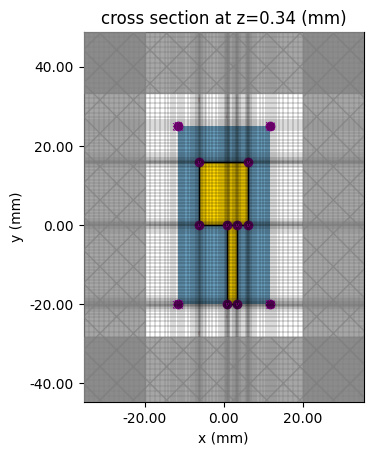

In [11]:
def params_to_boxes(patch_params):
    """Convert single patch parameters into patch geometry."""
    patch_wh = patch_params[0:2]
    main_patch = td.Box.from_bounds(
        [-0.5 * patch_wh[0], 0.0, sub_z / 2.0], [0.5 * patch_wh[0], patch_wh[1], sub_z / 2.0]
    )
    return [main_patch]


# set an initial width and height for the patch
patch_init_width = 12.45 * mm
patch_init_height = 16 * mm
patch_init_wh = anp.array([patch_init_width, patch_init_height])

# set the min/max for the patch width and height to use to bound these parameters in the optimization
patch_min_width = 8 * mm
patch_min_height = 8 * mm

patch_max_width = 18 * mm
patch_max_height = 24 * mm

# plot the patch and mesh of the initial structure to visually inspect geometry before starting optimization
plot_structures_and_mesh(params_to_boxes(patch_init_wh))

Now, we set up the optimization. We create the monitors to capture the far field radiation and solve for the initial flux into the target radiation angular components. Then, we configure the optimizer which we can also load from a saved checkpoint by toggling the `restart_optimization` flag if we get interrupted in the middle. When computing the initial values of `S11` and the radiated flux, we log the simulation cost to give an idea of how many FlexCredits it costs run. During the optimization loop, each iteration we compute the gradient, which requires two simulations. The cost per iteration will thus be double that of a single simulation except for the occasional iteration where we save additional simulation data for evaluation after the optimization. On those iterations, the cost will be 3x the single simulation cost. To reduce the number of the full evaluations, you can increase `full_eval_period`.

In [12]:
# Turn the logging level to only show errors to not crowd the optimization output with repeated warnings
td.config.logging.level = "ERROR"

# whether or not to restart the optimization from the current saved checkpoint
restart_optimization = False
restart_fname = "misc/rf_autograd_1_patch_opt_state.pkl"

# set up the single patch radiation monitor sizes
obj_fn_monitor_dim = 1.25 * np.mean(patch_init_wh)
obj_fn_monitor_center_y = 0.5 * patch_init_wh[1]

# compute initial poynting flux to be used in the objective function
initial_poynting_flux, initial_s11 = compute_poynting_and_s11(
    patch_init_wh, log_simulation_cost=True
)

12:45:19 CEST Billed flex credit cost: 0.025.

The antenna cost 0.025 FlexCredits to run. Each iteration of the optimization will cost around 0.050 FlexCredits to
complete.

Finally, we run the optimization and capture the figure of merit, `S11`, and gain metrics along the way.

In [13]:
# Set up the objective function for the single patch that is a function
# of the patch width and height. Using autograd, we can find the gradient
# of the objective function with respect to the first argument, which contains
# the (width, height) parameters describing the rectangular patch.
obj_val_and_grad = value_and_grad(objective_fn, argnum=[0])
patch_wh = patch_init_wh.copy()

# Set up optimization parameters and optimizer
learning_rate = 30
optimizer = adam(learning_rate=learning_rate, beta1=0.8)
opt_state = optimizer.init(patch_wh)

num_steps = 60

full_eval_period = 10
s11_sq_dB_evolution = []
s11_f_ghz = None
realized_gain_evolution = []

# Set bounds on patch width and height in the optimization
clip_min_single = anp.array([patch_min_width, patch_min_height])
clip_max_single = anp.array([patch_max_width, patch_max_height])

figure_of_merit = np.zeros(num_steps + 1)


def pack_optimization_state(iter_idx):
    optimization_state["iteration"] = iter_idx
    optimization_state["figure of merit"] = figure_of_merit
    optimization_state["realized gain evolution"] = realized_gain_evolution
    optimization_state["opt state"] = opt_state
    optimization_state["patch parameters"] = patch_wh


optimization_state = {}
if not os.path.exists(restart_fname):
    pack_optimization_state(iter_idx=0)

if restart_optimization:
    with open(restart_fname, "rb") as file:
        optimization_state = pickle.load(file)

start_idx = 0
if restart_optimization:
    start_idx = optimization_state["iteration"]
    figure_of_merit = optimization_state["figure of merit"]
    realized_gain_evolution = optimization_state["realized gain evolution"]
    opt_state = optimization_state["opt state"]
    patch_wh = optimization_state["patch parameters"]

# run optimization loop, updating the patch parameters with the `Adam` optimizer
# at each step and clipping the design on the bounds
for step_idx in range(start_idx, num_steps):
    pack_optimization_state(iter_idx=step_idx)
    with open(restart_fname, "wb") as file:
        pickle.dump(optimization_state, file)

    f, g = obj_val_and_grad(patch_wh, initial_poynting_flux)

    figure_of_merit[step_idx] = f

    if (step_idx % full_eval_period) == 0:
        smatrix_data_eval, realized_gain_eval = evaluate_antenna(patch_wh, freqs_s_params)
        smatrix_eval = smatrix_data_eval.smatrix()
        smatrix_f_ghz = smatrix_eval.data.coords["f"] / 1e9
        s11_f_ghz = smatrix_f_ghz.copy()
        s11_data_selection = smatrix_eval.data.isel(port_out=0, port_in=0)
        s11_sq_dB_evolution.append(20 * np.log10(np.abs(s11_data_selection.values.flatten())))

        realized_gain_evolution.append(
            {
                "Gtheta": realized_gain_eval["Gtheta"]
                .sel(phi=0, method="nearest")
                .squeeze()
                .values,
                "Gphi": realized_gain_eval["Gphi"].sel(phi=0, method="nearest").squeeze().values,
            }
        )

    updates, opt_state = optimizer.update(-g[0], opt_state, patch_wh)

    patch_wh = apply_updates(patch_wh, updates)
    patch_wh = anp.array(patch_wh)
    patch_wh = anp.clip(patch_wh, a_min=clip_min_single, a_max=clip_max_single)

    if (step_idx % print_iteration_frequency) == 0:
        output_text = Text.assemble(
            (f"Iteration {step_idx + 1}", "bold cyan"),
            "\n",
            ("\tParams (width, height) (mm): ", ""),
            (
                f"{(patch_wh[0] / mm):.{print_decimal_places}f}, {(patch_wh[1] / mm):.{print_decimal_places}f}",
                "blue",
            ),
            "\n",
            ("\tFigure of merit:          ", "bold"),
            (f"{f:.{print_decimal_places}f}", "bold green"),
        )
        console.print(output_text)

figure_of_merit[num_steps] = objective_fn(patch_wh, initial_poynting_flux)

Iteration 1
        Params (width, height) (mm): 12.42, 15.97
        Figure of merit:          0.11

Iteration 6
        Params (width, height) (mm): 12.28, 15.88
        Figure of merit:          0.12

Iteration 11
        Params (width, height) (mm): 12.14, 15.75
        Figure of merit:          0.15

Iteration 16
        Params (width, height) (mm): 11.99, 15.57
        Figure of merit:          0.18

Iteration 21
        Params (width, height) (mm): 11.83, 15.44
        Figure of merit:          0.25

...

Iteration 36
        Params (width, height) (mm): 11.15, 14.90
        Figure of merit:          1.60

Iteration 41
        Params (width, height) (mm): 10.88, 14.75
        Figure of merit:          5.46

Iteration 46
        Params (width, height) (mm): 10.61, 14.50
        Figure of merit:          16.97

Iteration 51
        Params (width, height) (mm): 10.47, 14.33
        Figure of merit:          20.09

Iteration 56
        Params (width, height) (mm): 10.56, 14.29
        Figure of merit:          20.40

Below, we plot the optimization output, including the figure of merit as a function of iteration and a comparison of the initial and final patch geometry. During the optimization, we also tracked how the `S11` coefficient and realized gain were evolving as the optimizer tuned the patch width and height. This evolution is visualized as well, showing the resonance moving towards the desired frequency and the antenna gain increasing accordingly. In the visualization the lines get darker moving from the beginning of the optimization to the end.

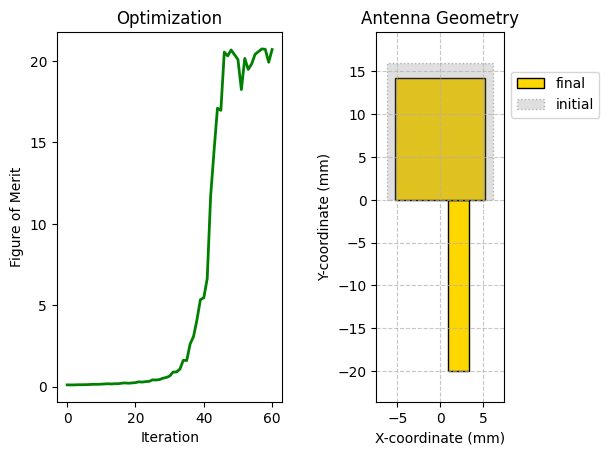

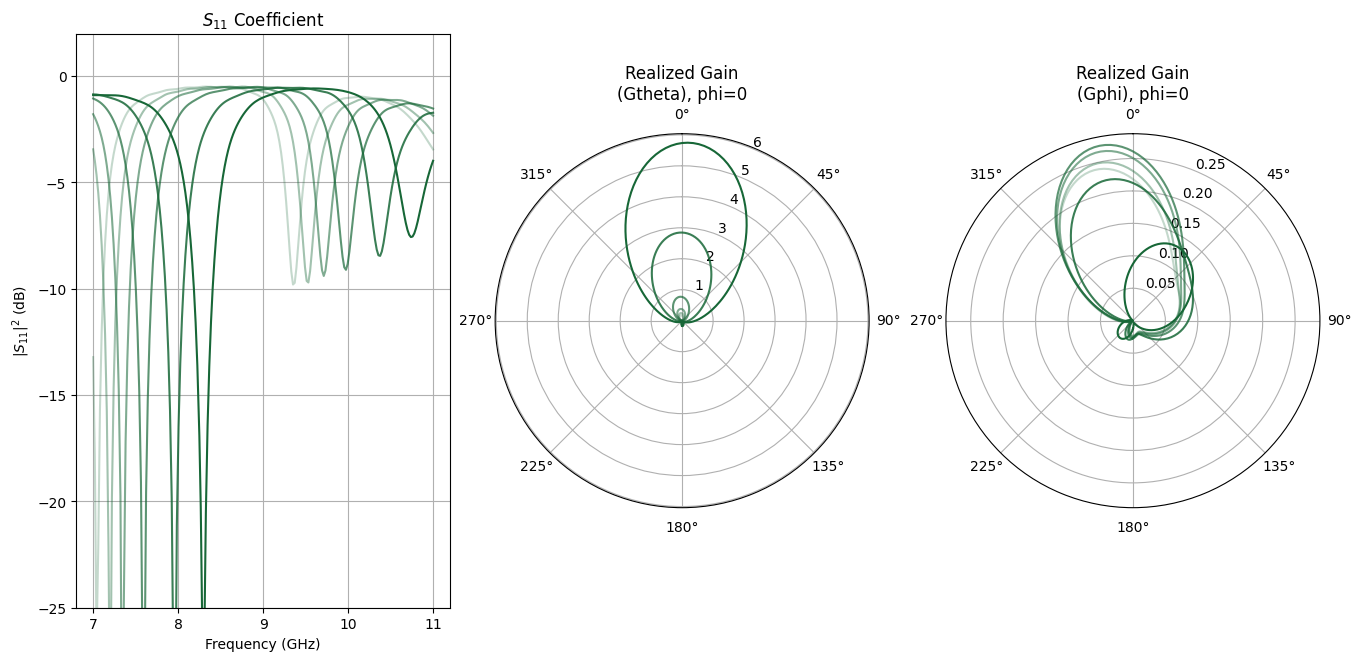

In [14]:
# Plot the results of the optimization including the optimization trajectory and the resulting patch geometry
# compared to the initial state
plot_optimization_results(
    figure_of_merit,
    td.Box(center=(feed_offset, -0.5 * feed_y, 0.0), size=(feed_x, feed_y, 0.0)),
    params_to_boxes(patch_init_wh),
    params_to_boxes(patch_wh),
)

# Plot the evolution of the antenna S11 and realized gain during the course of the optimization
plot_antenna_evolution(
    s11_sq_dB_evolution,
    s11_f_ghz,
    realized_gain_evolution,
    opt_freqs,
)

Now, we plot a performance comparison between our initial final antenna states including the realized gain for both polarization.

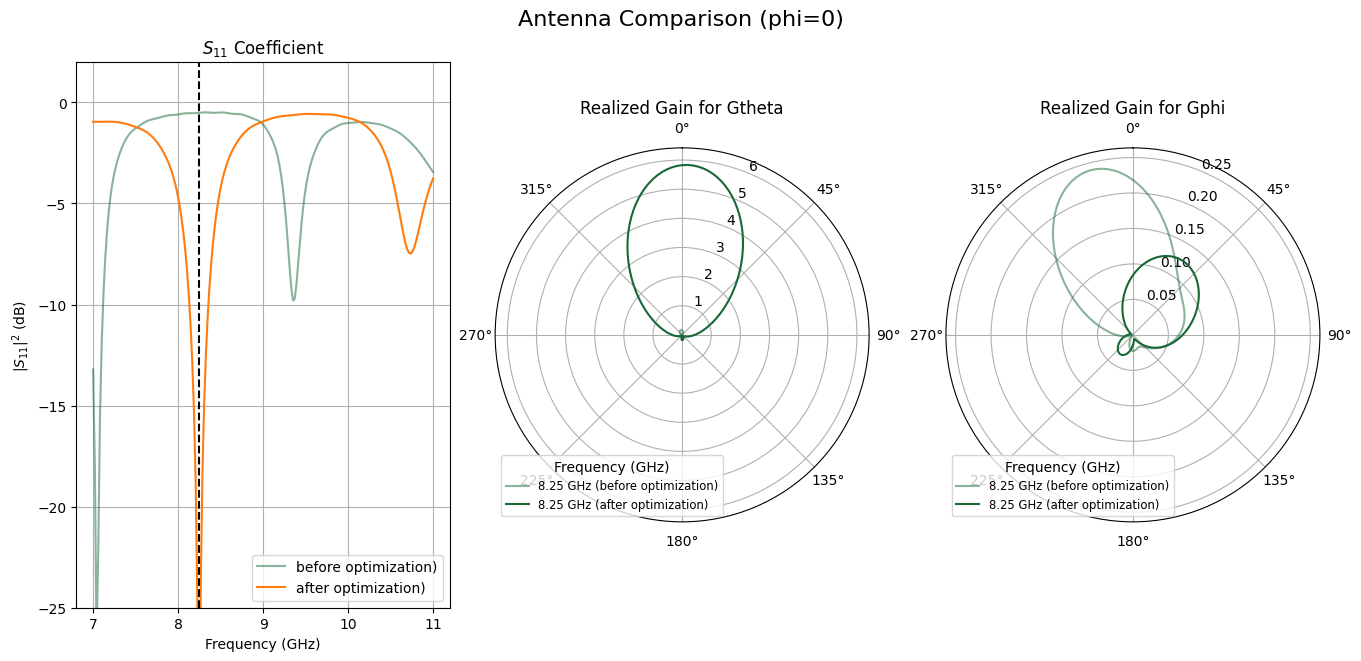

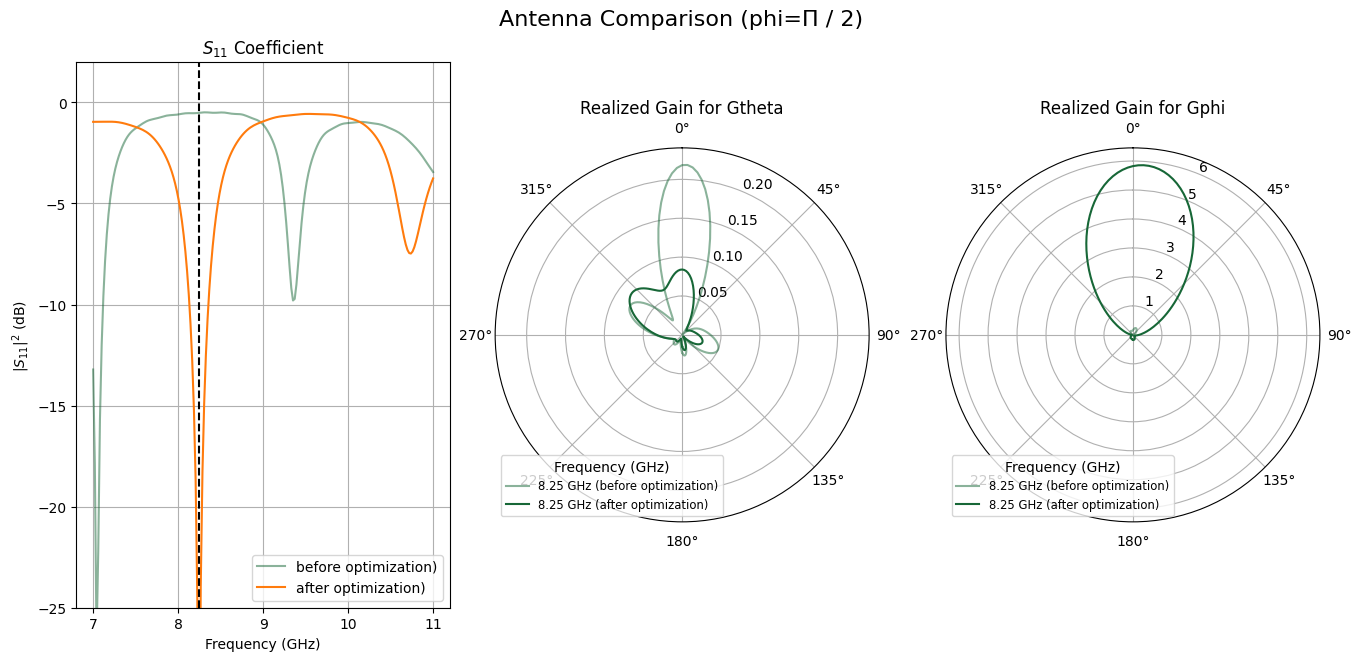

In [15]:
# Compute S11 and realized gain for the initial patch geometry
smatrix_data_init, realized_gain_init = evaluate_antenna(patch_init_wh, freqs_s_params)
# Compute S11 and realized gain for the optimized patch geometry
smatrix_data_final, realized_gain_final = evaluate_antenna(patch_wh, freqs_s_params)

# Plot the comparison in S11 and gain for the initial and optimized antennas for phi=0
plot_phi = 0.0
plot_antenna_comparison(
    [smatrix_data_init.smatrix(), smatrix_data_final.smatrix()],
    [smatrix_data_init.data, smatrix_data_final.data],
    [realized_gain_init, realized_gain_final],
    plot_phi,
    sim_names=["before optimization", "after optimization"],
    plot_title="Antenna Comparison (phi=0)",
)

# Plot the comparison in S11 and gain for the initial and optimized antennas for phi=pi / 2
plot_phi = np.pi / 2.0
plot_antenna_comparison(
    [smatrix_data_init.smatrix(), smatrix_data_final.smatrix()],
    [smatrix_data_init.data, smatrix_data_final.data],
    [realized_gain_init, realized_gain_final],
    plot_phi,
    sim_names=["before optimization", "after optimization"],
    plot_title="Antenna Comparison (phi=\u03a0 / 2)",
)
# Save results of optimization
np.save("misc/rf_autograd_1_patch_antenna_optimization.npy", patch_wh)

Inverse design and the adjoint method will become increasingly useful when the degrees of freedom in the optimization get larger and the target objective functions are more challenging. The goal of this notebook was to introduce the concept and show how we can use gradient-based optimization methods for RF in Tidy3D. In future notebooks, we will demonstrate how to take advantage of this process to find designs for dual-band patch antennas and other more challenging RF problems.